In [1]:
#! pip install scipy

In [2]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import random
import numpy as np
import torch
from itertools import product

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
env = gym.make("Blackjack-v1", sab=True)
env.reset(seed=SEED)
env.action_space.seed(SEED)

42

In [6]:
reward_log_sarsa = []
reward_log_double = []

In [38]:
def epsilon_greedy(Q, state, nA, epsilon):
    if random.random() < epsilon:
        return random.choice(range(nA))
    return np.argmax(Q[state])


In [39]:
def double_q_learning(env, num_episodes=1000000, alpha=0.1, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.9999):
    QA = defaultdict(lambda: np.zeros(env.action_space.n))
    QB = defaultdict(lambda: np.zeros(env.action_space.n))
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            Qsum = QA[state] + QB[state]
            Q_temp = defaultdict(lambda: np.zeros(env.action_space.n))
            Q_temp[state] = Qsum
            action = epsilon_greedy(Q_temp, state, env.action_space.n, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

            if random.random() < 0.5:
                best_next = np.argmax(QA[next_state])
                target = reward + gamma * QB[next_state][best_next]
                QA[state][action] += alpha * (target - QA[state][action])
            else:
                best_next = np.argmax(QB[next_state])
                target = reward + gamma * QA[next_state][best_next]
                QB[state][action] += alpha * (target - QB[state][action])

            state = next_state
        epsilon = max(min_epsilon, epsilon * decay)
        reward_log_double.append(episode_reward)
    Q_final = defaultdict(lambda: np.zeros(env.action_space.n))
    for state in set(QA.keys()).union(QB.keys()):
        Q_final[state] = (QA[state] + QB[state]) / 2.0
    return Q_final, reward_log_double

In [40]:
def expected_sarsa(env, num_episodes=1000000, alpha=0.1, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.9999):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

            policy_probs = np.ones(env.action_space.n) * (epsilon / env.action_space.n)
            best_action = np.argmax(Q[next_state])
            policy_probs[best_action] += (1.0 - epsilon)
            expected_q = np.dot(Q[next_state], policy_probs)

            Q[state][action] += alpha * (reward + gamma * expected_q - Q[state][action])
            state = next_state

        epsilon = max(min_epsilon, epsilon * decay)
        reward_log_sarsa.append(episode_reward)
    return Q, reward_log_sarsa

In [ ]:
# Grid search over hyperparameters
hyper_grid = list(product([0.01, 0.05, 0.1], [0.999, 0.9999, 0.99995], [0.01, 0.05, 0.1]))
best_sarsa, best_double = None, None
best_sarsa_score, best_double_score = -float("inf"), -float("inf")
best_sarsa_params, best_double_params = None, None

for alpha, decay, min_epsilon in hyper_grid:
    Qs, rewards_sarsa = expected_sarsa(env, alpha=alpha, decay=decay, min_epsilon=min_epsilon)
    Qd, rewards_double = double_q_learning(env, alpha=alpha, decay=decay, min_epsilon=min_epsilon)

    avg_reward_sarsa = np.mean(rewards_sarsa[-10000:])
    avg_reward_double = np.mean(rewards_double[-10000:])

    if avg_reward_sarsa > best_sarsa_score:
        best_sarsa_score = avg_reward_sarsa
        best_sarsa = Qs
        best_sarsa_params = (alpha, decay, min_epsilon)

    if avg_reward_double > best_double_score:
        best_double_score = avg_reward_double
        best_double = Qd
        best_double_params = (alpha, decay, min_epsilon)

In [ ]:
policy_sarsa = {s: np.argmax(a) for s, a in best_sarsa.items()}
policy_double = {s: np.argmax(a) for s, a in best_double.items()}

In [ ]:
print("Best SARSA α, decay:", best_sarsa_params, "Score:", best_sarsa_score)
print("Best Double Q-Learning α, decay:", best_double_params, "Score:", best_double_score)

Best SARSA α, decay: (0.1, 0.999) Score: -0.0958
Best Double Q-Learning α, decay: (0.05, 0.9999) Score: -0.1727


In [44]:
# Train agents
Q_sarsa, _ = expected_sarsa(env, num_episodes=1000000, alpha=0.05, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.9999)
Q_double, _ = double_q_learning(env, num_episodes=1000000, alpha=0.1, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.99995)

In [45]:
def plot_policy(policy, usable_ace=True, title="Learned Policy"):
    data = np.full((10, 10), '', dtype=object)
    for (player, dealer, ace), action in policy.items():
        if ace == usable_ace and 12 <= player <= 21 and 1 <= dealer <= 10:
            label = 'Hit' if action == 1 else 'Stick'
            data[21 - player, dealer - 1] = label  # flip the vertical index

    heatmap_vals = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            heatmap_vals[i, j] = 1 if data[i, j] == 'Hit' else 0

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_vals, annot=data, fmt="", cbar=False, cmap="coolwarm")
    plt.xticks(np.arange(10) + 0.5, np.arange(1, 11))
    plt.yticks(np.arange(10) + 0.5, list(reversed(np.arange(12, 22))))
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.title(f"{title} (Usable Ace = {usable_ace})")
    plt.show()


In [46]:
def plot_action_probabilities(Q, usable_ace=True, title="Action Probabilities"):
    hit_probs = np.full((10, 10), np.nan)
    for (player, dealer, ace), values in Q.items():
        if ace == usable_ace and 12 <= player <= 21 and 1 <= dealer <= 10:
            hit_probs[21 - player, dealer - 1] = values[1] / np.sum(values)

    plt.figure(figsize=(10, 6))
    sns.heatmap(hit_probs, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, cbar_kws={'label': 'P(Hit)'})
    plt.xticks(np.arange(10) + 0.5, np.arange(1, 11))
    plt.yticks(np.arange(10) + 0.5, np.arange(21, 11, -1))
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.title(f"{title} (Usable Ace = {usable_ace})")
    plt.show()

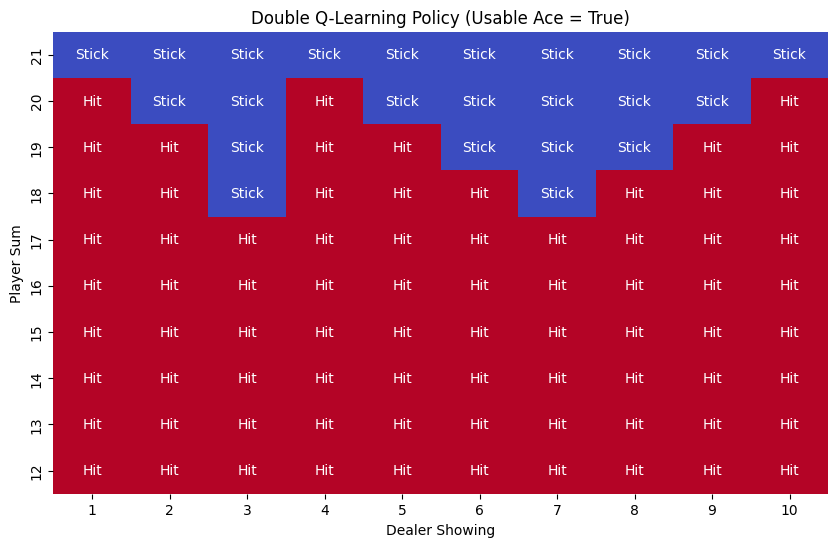

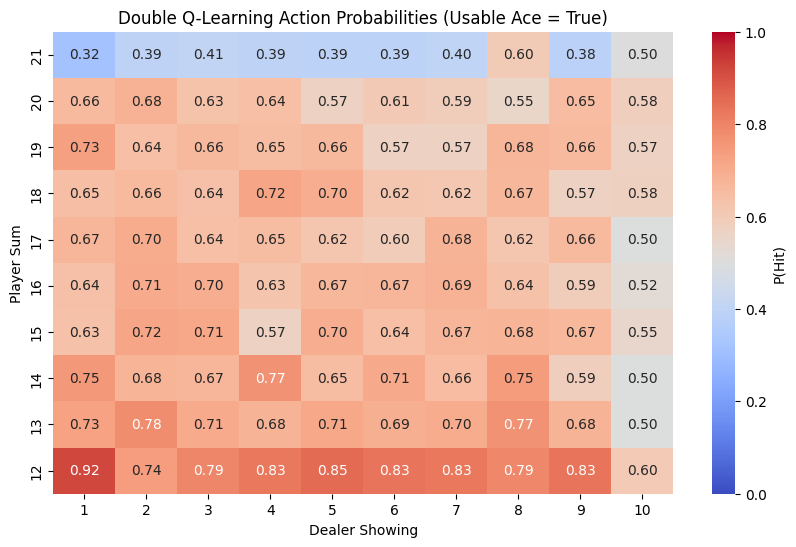

In [47]:
plot_policy(policy_double, usable_ace=True, title="Double Q-Learning Policy")
plot_action_probabilities(Q_double, usable_ace=True, title="Double Q-Learning Action Probabilities")

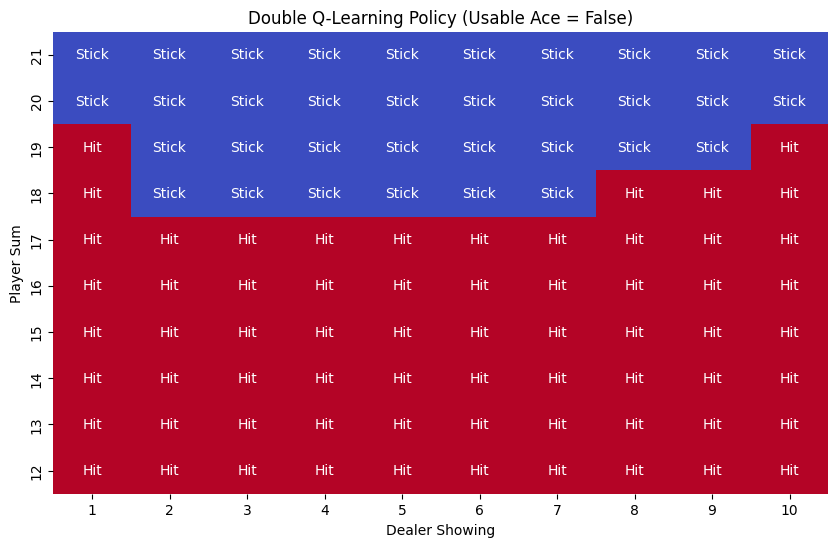

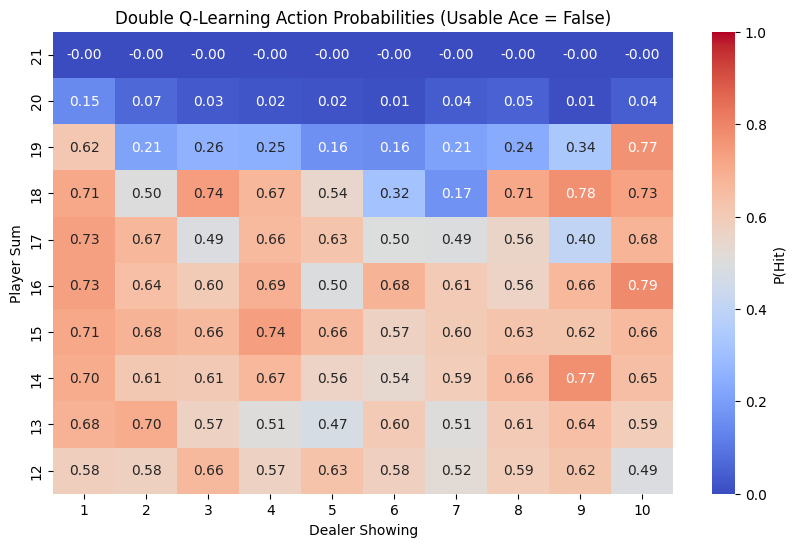

In [48]:
plot_policy(policy_double, usable_ace=False, title="Double Q-Learning Policy")
plot_action_probabilities(Q_double, usable_ace=False, title="Double Q-Learning Action Probabilities")

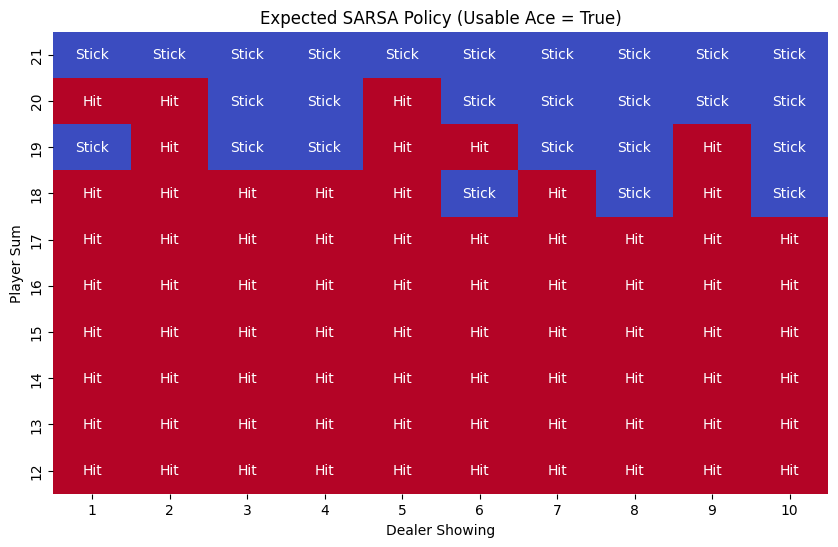

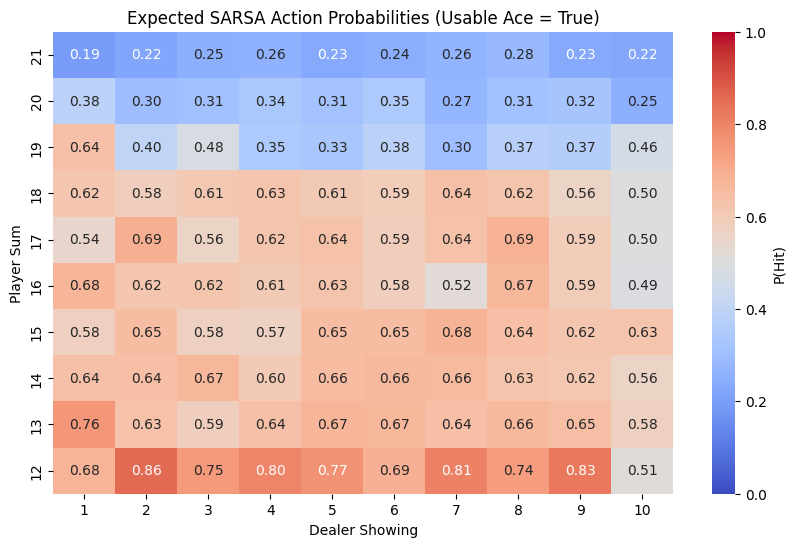

In [49]:
plot_policy(policy_sarsa, usable_ace=True, title="Expected SARSA Policy")
plot_action_probabilities(Q_sarsa, usable_ace=True, title="Expected SARSA Action Probabilities")

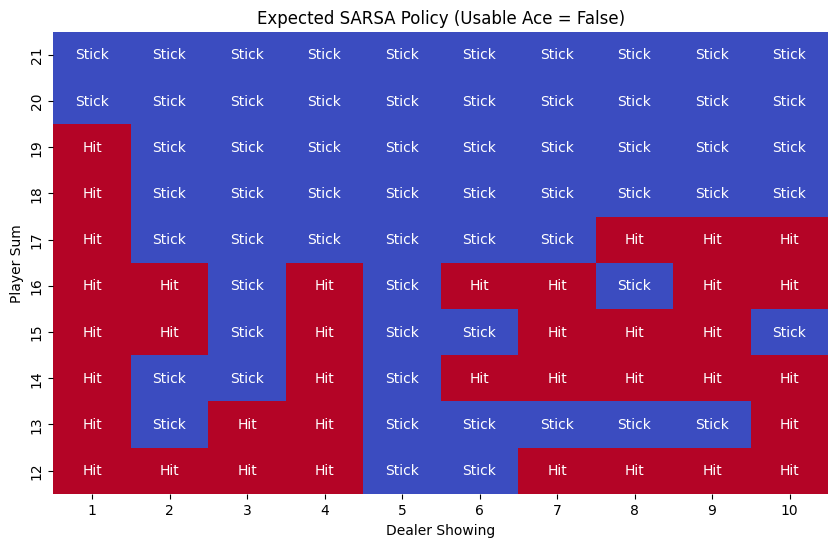

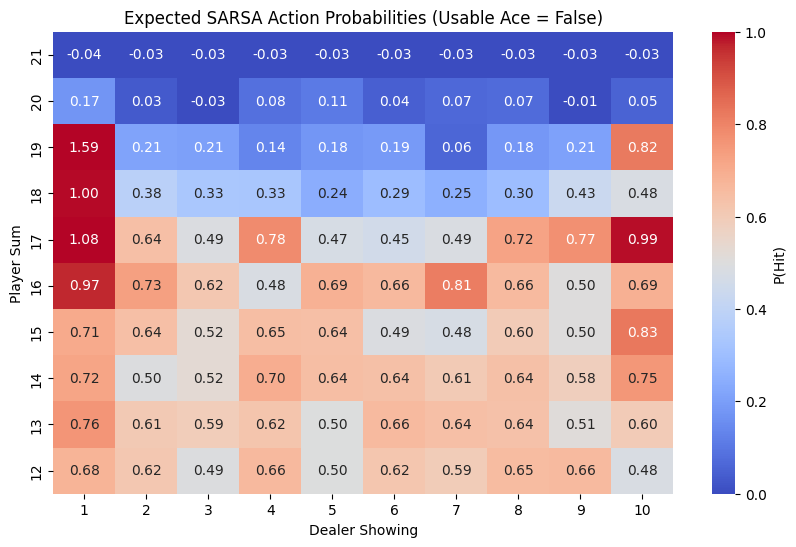

In [50]:
# Plot action probabilities
plot_policy(policy_sarsa, usable_ace=False, title="Expected SARSA Policy")
plot_action_probabilities(Q_sarsa, usable_ace=False, title="Expected SARSA Action Probabilities")

In [51]:
def evaluate_policy(policy, num_episodes=10000):
    results = {"win": 0, "lose": 0, "draw": 0}
    rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = policy.get(state, 0)  # default to stick
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)
        if reward > 0:
            results["win"] += 1
        elif reward < 0:
            results["lose"] += 1
        else:
            results["draw"] += 1

    total = sum(results.values())
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    ci95 = norm.interval(0.95, loc=mean_reward, scale=std_reward / np.sqrt(num_episodes))

    print("Evaluation Results ({} episodes):".format(num_episodes))
    for k, v in results.items():
        print(f"{k.capitalize()}: {v} ({100 * v / total:.2f}%)")
    print(f"Mean Reward: {mean_reward:.4f}, 95% CI: ({ci95[0]:.4f}, {ci95[1]:.4f})")

In [52]:
evaluate_policy(policy_double)

Evaluation Results (10000 episodes):
Win: 3719 (37.19%)
Lose: 5562 (55.62%)
Draw: 719 (7.19%)
Mean Reward: -0.1843, 95% CI: (-0.2028, -0.1658)


In [53]:
evaluate_policy(policy_sarsa)

Evaluation Results (10000 episodes):
Win: 4090 (40.90%)
Lose: 5046 (50.46%)
Draw: 864 (8.64%)
Mean Reward: -0.0956, 95% CI: (-0.1142, -0.0770)


In [54]:
import pandas as pd

# Plot training reward curves
window = 5000

double_smoothed = pd.Series(reward_log_double).rolling(window).mean()
sarsa_smoothed = pd.Series(reward_log_sarsa).rolling(window).mean()

plt.figure(figsize=(12, 6))
plt.plot(sarsa_smoothed, label="Expected SARSA")
plt.plot(double_smoothed, label="Double Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.title("Training Reward Curves ({}-Episode Moving Average)".format(window))
plt.legend()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Plot Value Function Heatmaps
def plot_value_function(Q, usable_ace=True, title="Value Function"):
    value = np.full((10, 10), np.nan)
    annotations = np.full((10, 10), '', dtype=object)
    for (player, dealer, ace), actions in Q.items():
        if ace == usable_ace and 12 <= player <= 21 and 1 <= dealer <= 10:
            val = np.max(actions)
            value[21 - player, dealer - 1] = val
            annotations[21 - player, dealer - 1] = f"{val:.2f}"

    best_state = np.unravel_index(np.nanargmax(value), value.shape)

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(value, cmap="viridis", annot=annotations, fmt="", xticklabels=np.arange(1, 11), yticklabels=np.arange(21, 11, -1))
    ax.add_patch(plt.Rectangle((best_state[1], best_state[0]), 1, 1, fill=False, edgecolor='red', lw=2))
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.title(f"{title} (Usable Ace = {usable_ace})")
    plt.show()

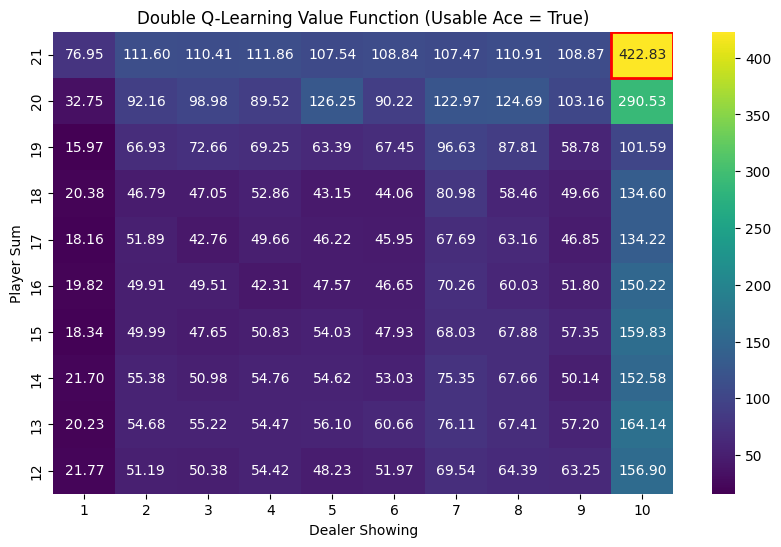

In [ ]:
plot_value_function(Q_double, usable_ace=True, title="Double Q-Learning Value Function")

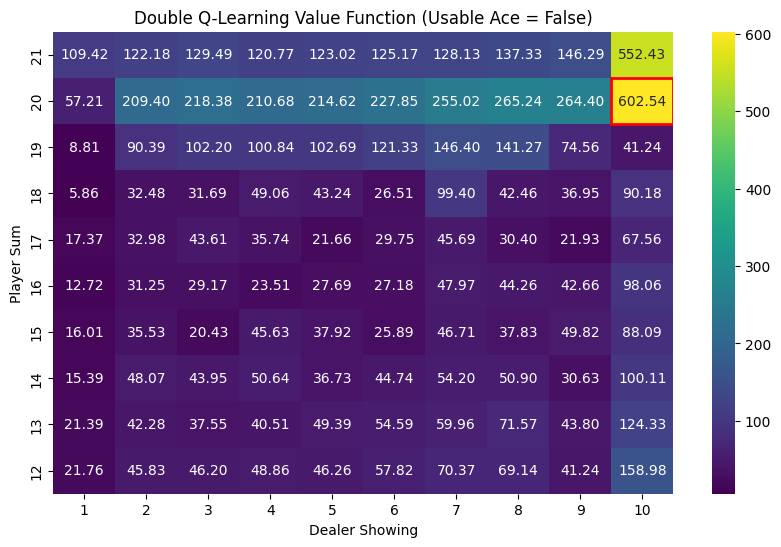

In [ ]:
plot_value_function(Q_double, usable_ace=False, title="Double Q-Learning Value Function")

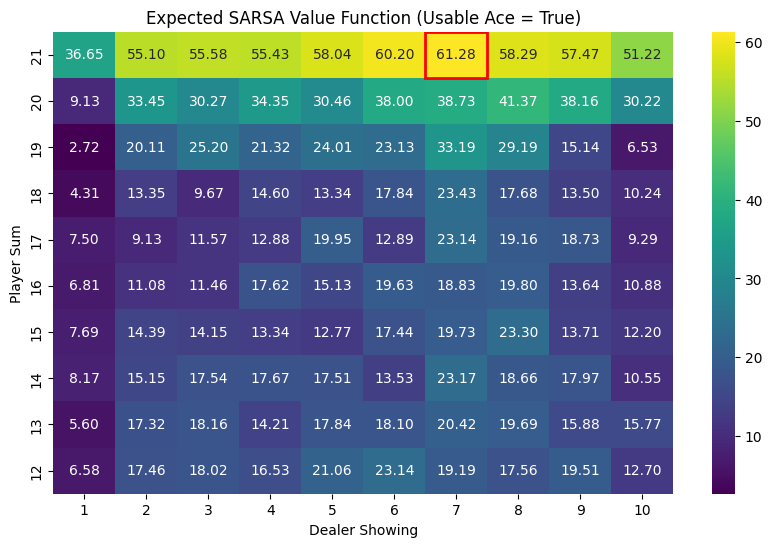

In [ ]:
plot_value_function(Q_sarsa, usable_ace=True, title="Expected SARSA Value Function")

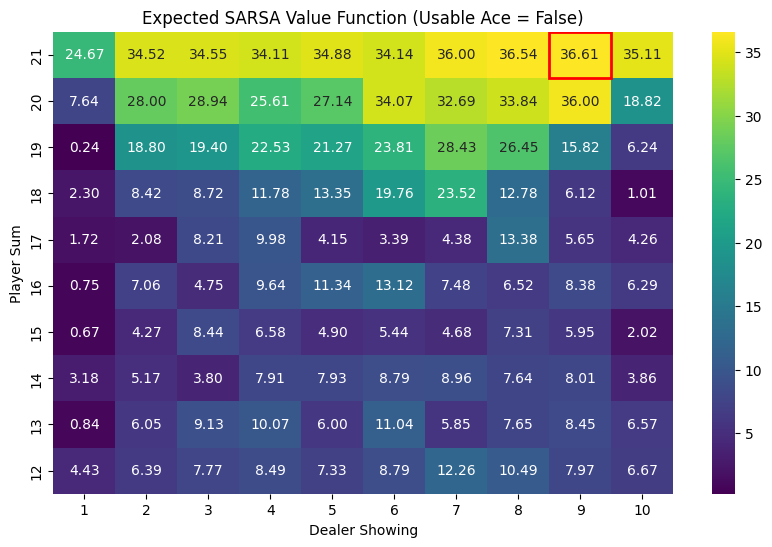

In [ ]:
plot_value_function(Q_sarsa, usable_ace=False, title="Expected SARSA Value Function")

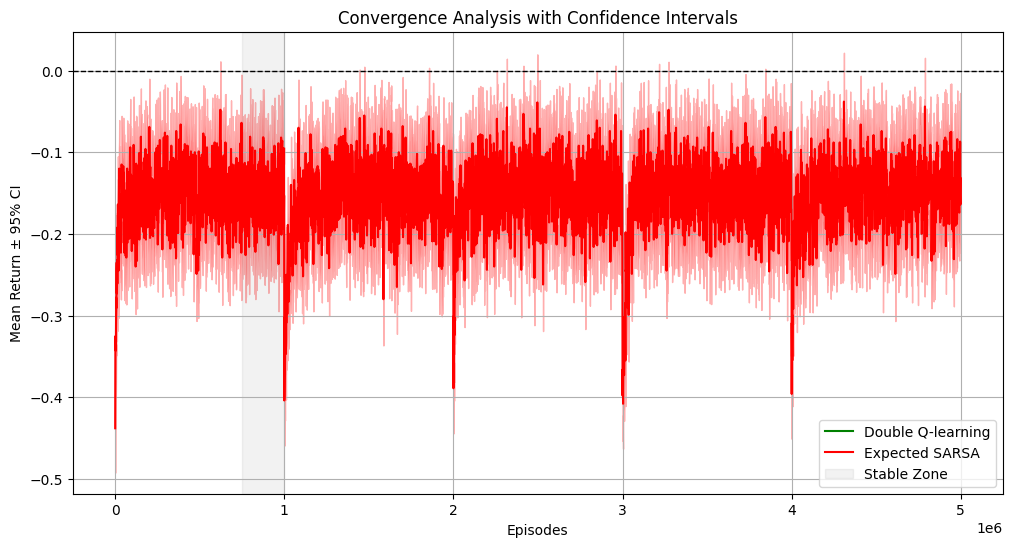

In [ ]:
from scipy.stats import sem

def chunked_statistics_with_ci(rewards, chunk_size=1000):
    chunks = [rewards[i:i+chunk_size] for i in range(0, len(rewards), chunk_size)]
    means = [np.mean(chunk) for chunk in chunks]
    errors = [1.96 * sem(chunk) for chunk in chunks]  # 95% CI
    return means, errors

means_q, ci_q = chunked_statistics_with_ci(reward_log_double)
means_sarsa, ci_sarsa = chunked_statistics_with_ci(reward_log_sarsa)
episodes_q = np.arange(len(means_q)) * 1000
episodes_sarsa = np.arange(len(means_sarsa)) * 1000


plt.figure(figsize=(12, 6))
plt.plot(episodes_q, means_q, label='Double Q-learning', color='green')
plt.fill_between(episodes_q, np.array(means_q) - ci_q, np.array(means_q) + ci_q, alpha=0.3, color='green')

plt.plot(episodes_sarsa, means_sarsa, label='Expected SARSA', color='red')
plt.fill_between(episodes_sarsa, np.array(means_sarsa) - ci_sarsa, np.array(means_sarsa) + ci_sarsa, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvspan(0.75e6, 1e6, color='gray', alpha=0.1, label='Stable Zone')

#rolling_q = pd.Series(means_q).rolling(10).mean()
#rolling_sarsa = pd.Series(means_sarsa).rolling(10).mean()
#plt.plot(episodes_q, rolling_q, color='green', linestyle='--')
#plt.plot(episodes_sarsa, rolling_sarsa, color='red', linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Mean Return ± 95% CI")
plt.title("Convergence Analysis with Confidence Intervals")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print(np.mean(reward_log_double), np.std(reward_log_double))
print(reward_log_double[:10])  # Check early values